# Linear Regression

In [0]:
import pandas as pd
import numpy as np
import joblib
import os

# Model building
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow 
import mlflow.sklearn

In [0]:
X_train_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/x_train_delta3")
X_train = X_train_spark.toPandas()
X_train.drop(['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category', "Price_per_HP", "Price_per_Seat"], axis=1, inplace=True)

y_train_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/y_train_delta3")
y_train = y_train_spark.toPandas()

X_test_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/x_test_delta3")
X_test = X_test_spark.toPandas()
X_test.drop(['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category', "Price_per_HP", "Price_per_Seat"], axis=1, inplace=True)

y_test_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/y_test_delta3")
y_test = y_test_spark.toPandas()

Train

In [0]:
X_train

,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,Seats,Torque,HP_per_CC,HP_Acceleration_Effectiveness,Cylinders
0,0.707917,0.334525,-0.699683,0.137710,-0.057802,-0.105493,-0.103231,-0.173633,0.850704
1,-0.723922,-1.325646,-0.361610,0.752626,-0.057802,-0.707507,-0.104392,-0.969242,-1.304643
2,1.871994,1.521548,0.158502,-0.541934,1.412626,0.765953,-0.103522,0.865392,2.287602
3,-0.247437,0.085500,1.198726,-0.768482,-0.793016,0.092371,-0.096431,0.170287,-0.586194
4,0.051931,-0.528764,-0.361610,0.428986,1.412626,-0.560161,-0.104180,-0.621147,-0.586194
...,...,...,...,...,...,...,...,...,...
829,-0.546805,-1.242637,-0.491638,1.302814,-0.057802,-0.454914,-0.105428,-0.979038,-1.304643
830,0.348318,1.289124,1.198726,-1.027395,-0.057802,0.408113,-0.095612,1.315032,0.850704
831,0.286893,1.803777,1.978894,-1.221579,-0.793016,1.355337,-0.091940,2.109234,0.850704
832,1.938189,1.131408,0.418558,-0.477206,-0.057802,1.144842,-0.104899,0.580100,2.287602


In [0]:
with mlflow.start_run() as run:

    model = LinearRegression().fit(X_train, y_train)
    model.fit(X_train, y_train['cars_prices'])

    mlflow.log_metric('train score', model.score(X_train, y_train['cars_prices']))

    mlflow.sklearn.log_model(
        sk_model=model,
        name='model',
        registered_model_name='lr',
        input_example=X_train.head(5)
    )

🔗 View Logged Model at: https://dbc-ee0b89ab-29c3.cloud.databricks.com/ml/experiments/4366753362691854/models/m-1863c3b99e88426f80c74b5683e9462e?o=2522432660463639
Registered model 'lr' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '14' of model 'workspace.default.lr': https://dbc-ee0b89ab-29c3.cloud.databricks.com/explore/data/models/workspace/default/lr/version/14?o=2522432660463639


In [0]:
lr = LinearRegression()

# Fit on full training set and save
lr.fit(X_train, y_train)

LinearRegression()

In [0]:
lr.score(X_train, y_train) * 100

77.20204938135346

In [0]:
lr.score(X_test, y_test) * 100

74.24035208121735

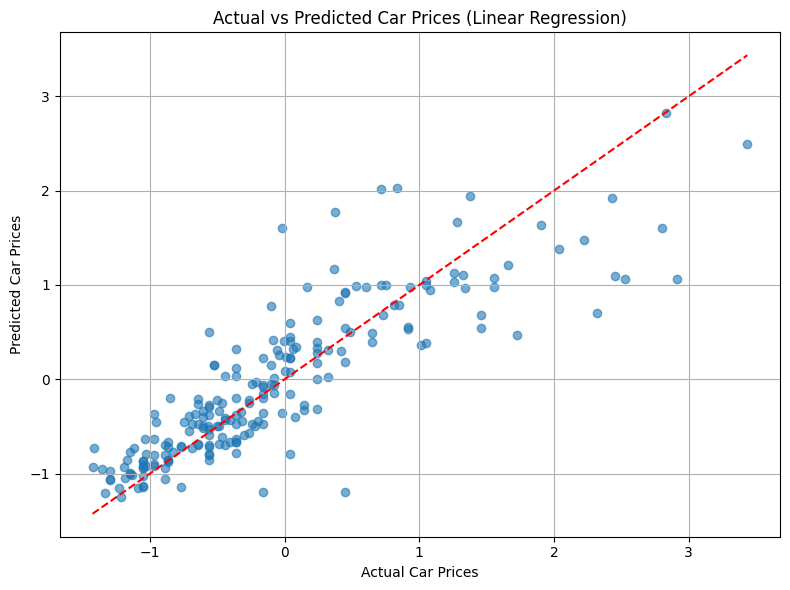

In [0]:
import matplotlib.pyplot as plt

# Predict on test set
y_pred = lr.predict(X_test)

# Visualize actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test['cars_prices'], y_pred, alpha=0.6)
plt.xlabel('Actual Car Prices')
plt.ylabel('Predicted Car Prices')
plt.title('Actual vs Predicted Car Prices (Linear Regression)')
plt.plot([y_test['cars_prices'].min(), y_test['cars_prices'].max()],
         [y_test['cars_prices'].min(), y_test['cars_prices'].max()],
         color='red', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

In [0]:
results = []

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append([mae, mse, r2])

In [0]:
results = pd.DataFrame(results, columns=["MAE", "MSE", "R² Score"])
results

,MAE,MSE,R² Score
0,0.32885,0.226861,0.742404
